# Change of Variables & the Jacobian Determinant

**Track:** Multivariable Integral Calculus (Topic 2 of 4)  
**Prerequisites:** Multiple Integrals & Fubini's Theorem (Topic 13), Inverse & Implicit Function Theorems (Topic 12)  
**Difficulty:** Intermediate

This notebook generates publication-quality static figures for the **Change of Variables** topic on [formalcalculus.com](https://www.formalcalculus.com). Each section produces one figure saved to the `figures/` directory.

**Key results:**
- The change of variables formula: $\iint_D f(x,y)\,dA = \iint_{D^*} f(\varphi(u,v))\,|\det J_\varphi(u,v)|\,du\,dv$
- Polar coordinates: $dA = r\,dr\,d\theta$
- The Gaussian integral: $\int_{-\infty}^{\infty} e^{-x^2}\,dx = \sqrt{\pi}$
- Spherical coordinates: $dV = \rho^2\sin\phi\,d\rho\,d\theta\,d\phi$
- Density transformation: $p_X(x) = p_Z(\varphi^{-1}(x))\,|\det J_{\varphi^{-1}}(x)|$

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyArrowPatch, Polygon
from matplotlib.collections import PatchCollection, PolyCollection
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.colors as mcolors
from scipy import integrate

# Matplotlib config
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.2,
})

# Color palette (consistent with formalCalculus)
BLUE = '#2563eb'
RED = '#dc2626'
GREEN = '#16a34a'
ORANGE = '#ea580c'
PURPLE = '#7c3aed'
TEAL = '#0d9488'
GRAY = '#6b7280'
LIGHT_BLUE = '#93c5fd'
LIGHT_RED = '#fca5a5'
LIGHT_GREEN = '#86efac'
LIGHT_ORANGE = '#fdba74'
LIGHT_PURPLE = '#c4b5fd'

# Output directory
import os
os.makedirs('figures', exist_ok=True)

print('Setup complete.')

Setup complete.


## 1. One-Dimensional Substitution Review

The substitution rule in 1D is the template for the multivariable change of variables formula. If $g: [\alpha, \beta] \to [a, b]$ is a $C^1$ bijection, then $\int_a^b f(x)\,dx = \int_\alpha^\beta f(g(t))\,|g'(t)|\,dt$. The factor $|g'(t)|$ is the 1D "Jacobian determinant" — it measures how $g$ stretches or compresses the interval. We visualize $\int_0^1 \sqrt{1 - x^2}\,dx$ via the substitution $x = \sin\theta$, which maps $[0, \pi/2]$ to $[0, 1]$.

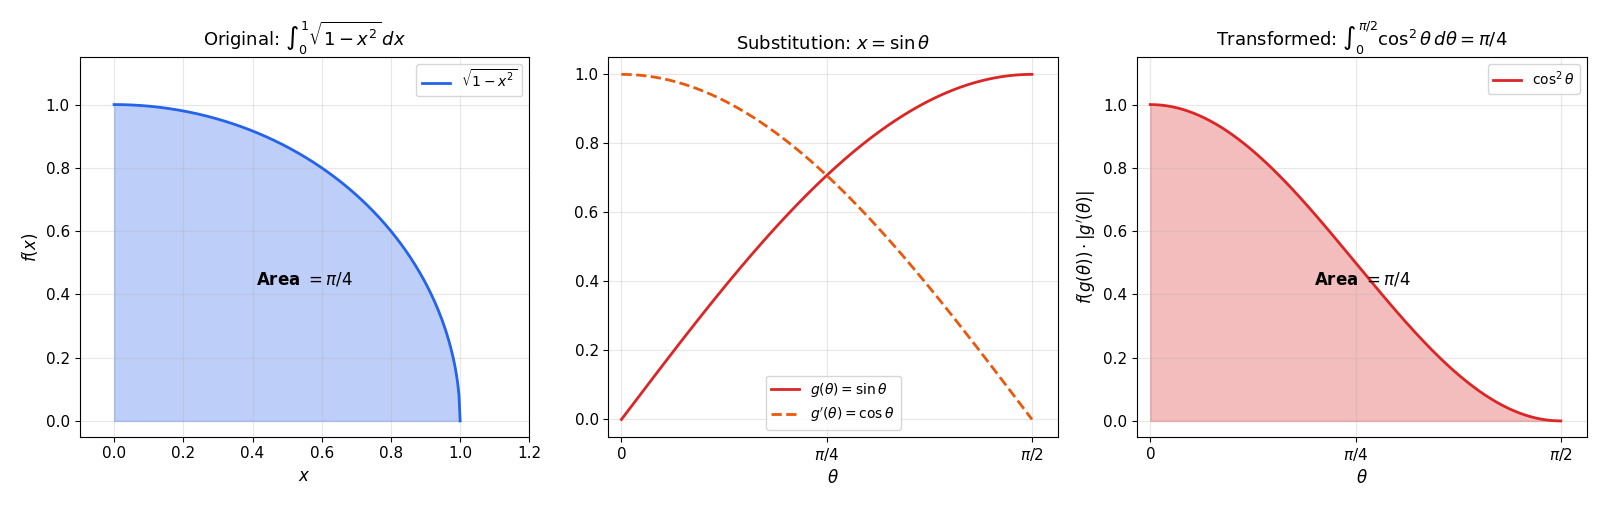

Figure 1 saved: 1d-substitution.png


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: original integral in x
x = np.linspace(0, 1, 300)
y = np.sqrt(1 - x**2)
axes[0].fill_between(x, 0, y, alpha=0.3, color=BLUE)
axes[0].plot(x, y, color=BLUE, linewidth=2, label=r'$\sqrt{1 - x^2}$')
axes[0].set_xlabel(r'$x$')
axes[0].set_ylabel(r'$f(x)$')
axes[0].set_title(r'Original: $\int_0^1 \sqrt{1 - x^2}\,dx$')
axes[0].set_xlim(-0.1, 1.2)
axes[0].set_ylim(-0.05, 1.15)
axes[0].legend(fontsize=10)

# Center: the substitution map g(theta) = sin(theta)
theta = np.linspace(0, np.pi/2, 300)
g = np.sin(theta)
gprime = np.cos(theta)
axes[1].plot(theta, g, color=RED, linewidth=2, label=r'$g(\theta) = \sin\theta$')
axes[1].plot(theta, gprime, color=ORANGE, linewidth=2, linestyle='--', label=r"$g'(\theta) = \cos\theta$")
axes[1].set_xlabel(r'$\theta$')
axes[1].set_title(r'Substitution: $x = \sin\theta$')
axes[1].set_xlim(-0.05, np.pi/2 + 0.1)
axes[1].legend(fontsize=10)
axes[1].set_xticks([0, np.pi/4, np.pi/2])
axes[1].set_xticklabels([r'$0$', r'$\pi/4$', r'$\pi/2$'])

# Right: transformed integral in theta
integrand = np.cos(theta)**2
axes[2].fill_between(theta, 0, integrand, alpha=0.3, color=RED)
axes[2].plot(theta, integrand, color=RED, linewidth=2, label=r'$\cos^2\theta$')
axes[2].set_xlabel(r'$\theta$')
axes[2].set_ylabel(r"$f(g(\theta)) \cdot |g'(\theta)|$")
axes[2].set_title(r'Transformed: $\int_0^{\pi/2} \cos^2\theta\,d\theta = \pi/4$')
axes[2].set_xlim(-0.05, np.pi/2 + 0.1)
axes[2].set_ylim(-0.05, 1.15)
axes[2].set_xticks([0, np.pi/4, np.pi/2])
axes[2].set_xticklabels([r'$0$', r'$\pi/4$', r'$\pi/2$'])
axes[2].legend(fontsize=10)

# Both areas equal pi/4
for ax in [axes[0], axes[2]]:
    ax.annotate(r'Area $= \pi/4$', xy=(0.5, 0.4), fontsize=12, color='black',
                ha='center', fontweight='bold', xycoords='axes fraction')

plt.tight_layout()
plt.savefig('figures/1d-substitution.png')
plt.show()
print('Figure 1 saved: 1d-substitution.png')

## 2. Change of Variables in 2D — Grid Deformation

The change of variables formula $\iint_D f(x,y)\,dA = \iint_{D^*} f(\varphi(u,v))\,|\det J_\varphi(u,v)|\,du\,dv$ transforms integrals from one coordinate system to another. The Jacobian determinant $|\det J_\varphi|$ measures how $\varphi$ distorts area elements. We visualize this by drawing a uniform grid in the parameter space $(u,v)$ and showing how $\varphi$ deforms it into curvilinear cells in the image space $(x,y)$, with cells colored by $|\det J_\varphi|$.

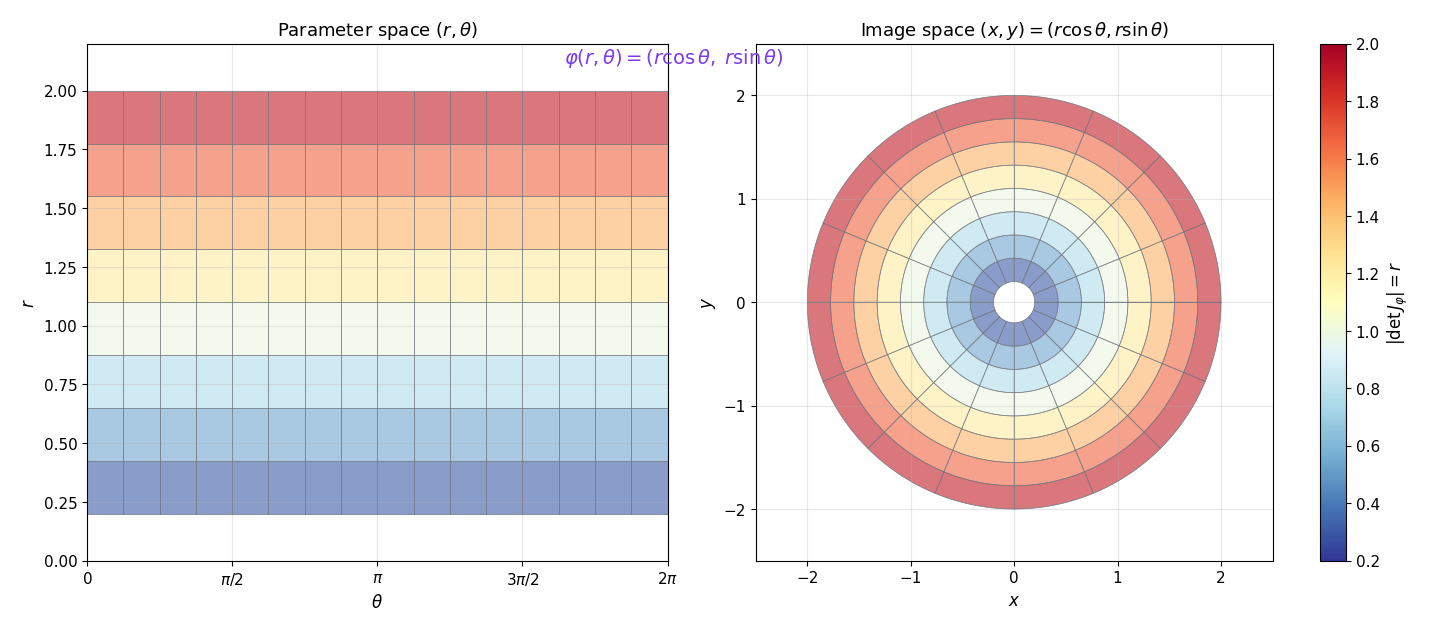

Figure 2 saved: change-of-variables-2d.png


In [3]:
def polar_map(r, theta):
    return r * np.cos(theta), r * np.sin(theta)

def polar_detJ(r, theta):
    return r

fig, axes = plt.subplots(1, 2, figsize=(14, 6), layout="constrained")

# Grid parameters
nr, ntheta = 8, 16
r_vals = np.linspace(0.2, 2.0, nr + 1)
theta_vals = np.linspace(0, 2 * np.pi, ntheta + 1)

# Left: uniform grid in (r, theta) parameter space
for r in r_vals:
    axes[0].plot([0, 2*np.pi], [r, r], color=GRAY, linewidth=0.5, alpha=0.7)
for t in theta_vals:
    axes[0].plot([t, t], [0.2, 2.0], color=GRAY, linewidth=0.5, alpha=0.7)

# Color cells by Jacobian determinant
norm = mcolors.Normalize(vmin=0.2, vmax=2.0)
cmap = plt.cm.RdYlBu_r

patches_param = []
colors_param = []
for i in range(nr):
    for j in range(ntheta):
        r_c = (r_vals[i] + r_vals[i+1]) / 2
        t_c = (theta_vals[j] + theta_vals[j+1]) / 2
        rect = plt.Rectangle((theta_vals[j], r_vals[i]),
                              theta_vals[j+1] - theta_vals[j],
                              r_vals[i+1] - r_vals[i])
        patches_param.append(rect)
        colors_param.append(polar_detJ(r_c, t_c))

pc = PatchCollection(patches_param, cmap=cmap, norm=norm, alpha=0.6, edgecolors='gray', linewidths=0.5)
pc.set_array(np.array(colors_param))
axes[0].add_collection(pc)

axes[0].set_xlabel(r'$\theta$')
axes[0].set_ylabel(r'$r$')
axes[0].set_title(r'Parameter space $(r, \theta)$')
axes[0].set_xlim(0, 2*np.pi)
axes[0].set_ylim(0, 2.2)
axes[0].set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
axes[0].set_xticklabels([r'$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])

# Right: deformed grid in (x, y) image space
for t in theta_vals:
    r_line = np.linspace(0.2, 2.0, 100)
    x_line, y_line = polar_map(r_line, t)
    axes[1].plot(x_line, y_line, color=GRAY, linewidth=0.5, alpha=0.7)
for r in r_vals:
    t_line = np.linspace(0, 2*np.pi, 200)
    x_line, y_line = polar_map(r, t_line)
    axes[1].plot(x_line, y_line, color=GRAY, linewidth=0.5, alpha=0.7)

# Color polar cells
polys = []
colors_image = []
for i in range(nr):
    for j in range(ntheta):
        r_c = (r_vals[i] + r_vals[i+1]) / 2
        t_fine = np.linspace(theta_vals[j], theta_vals[j+1], 20)
        x_bot, y_bot = polar_map(r_vals[i], t_fine)
        x_top, y_top = polar_map(r_vals[i+1], t_fine[::-1])
        verts = list(zip(np.concatenate([x_bot, x_top]),
                         np.concatenate([y_bot, y_top])))
        polys.append(verts)
        colors_image.append(polar_detJ(r_c, 0))

pc2 = PolyCollection(polys, cmap=cmap, norm=norm, alpha=0.6, edgecolors='gray', linewidths=0.5)
pc2.set_array(np.array(colors_image))
axes[1].add_collection(pc2)

axes[1].set_xlabel(r'$x$')
axes[1].set_ylabel(r'$y$')
axes[1].set_title(r'Image space $(x, y) = (r\cos\theta, r\sin\theta)$')
axes[1].set_xlim(-2.5, 2.5)
axes[1].set_ylim(-2.5, 2.5)
axes[1].set_aspect('equal')

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, fraction=0.03, pad=0.04)
cbar.set_label(r'$|\det J_\varphi| = r$', fontsize=12)

fig.text(0.47, 0.92, r'$\varphi(r,\theta) = (r\cos\theta,\; r\sin\theta)$',
         fontsize=14, ha='center', color=PURPLE, fontweight='bold')

plt.savefig('figures/change-of-variables-2d.png')
plt.show()
print('Figure 2 saved: change-of-variables-2d.png')

## 3. Polar Coordinates — The Canonical Example

Polar coordinates are the prototypical 2D change of variables. The map $\varphi(r, \theta) = (r\cos\theta, r\sin\theta)$ has Jacobian determinant $|\det J_\varphi| = r$, giving the area element $dA = r\,dr\,d\theta$. We compare the Cartesian and polar computations of the unit disk area, showing how polar coordinates reduce a painful Cartesian integral to a trivial product of 1D integrals. This resolves the disk integral from Topic 13, Example 7.

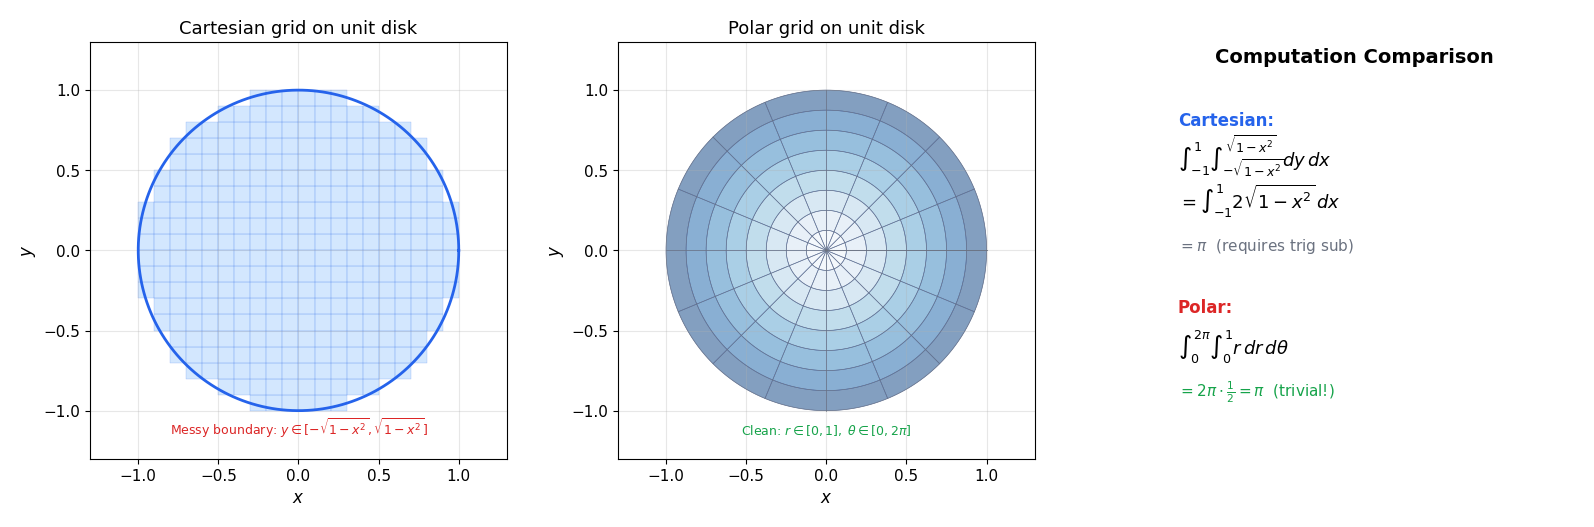

Figure 3 saved: polar-coordinates.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: Cartesian grid on the unit disk
n_cart = 20
x_grid = np.linspace(-1, 1, n_cart + 1)
y_grid = np.linspace(-1, 1, n_cart + 1)
theta_circle = np.linspace(0, 2*np.pi, 200)

axes[0].plot(np.cos(theta_circle), np.sin(theta_circle), color=BLUE, linewidth=2)
for i in range(n_cart):
    for j in range(n_cart):
        xc = (x_grid[i] + x_grid[i+1]) / 2
        yc = (y_grid[j] + y_grid[j+1]) / 2
        if xc**2 + yc**2 <= 1:
            rect = plt.Rectangle((x_grid[i], y_grid[j]),
                                 x_grid[i+1] - x_grid[i],
                                 y_grid[j+1] - y_grid[j],
                                 facecolor=LIGHT_BLUE, edgecolor=BLUE, alpha=0.4, linewidth=0.3)
            axes[0].add_patch(rect)

axes[0].set_xlabel(r'$x$')
axes[0].set_ylabel(r'$y$')
axes[0].set_title('Cartesian grid on unit disk')
axes[0].set_xlim(-1.3, 1.3)
axes[0].set_ylim(-1.3, 1.3)
axes[0].set_aspect('equal')
axes[0].text(0, -1.15, r'Messy boundary: $y \in [-\sqrt{1-x^2}, \sqrt{1-x^2}]$',
             ha='center', fontsize=9, color=RED)

# Center: Polar grid on the unit disk
nr_polar, ntheta_polar = 8, 16
r_p = np.linspace(0, 1, nr_polar + 1)
theta_p = np.linspace(0, 2*np.pi, ntheta_polar + 1)

for r in r_p[1:]:
    t_line = np.linspace(0, 2*np.pi, 200)
    axes[1].plot(r * np.cos(t_line), r * np.sin(t_line), color=GRAY, linewidth=0.5)
for t in theta_p:
    axes[1].plot([0, np.cos(t)], [0, np.sin(t)], color=GRAY, linewidth=0.5)

polys = []
colors = []
for i in range(nr_polar):
    for j in range(ntheta_polar):
        r_c = (r_p[i] + r_p[i+1]) / 2
        t_fine = np.linspace(theta_p[j], theta_p[j+1], 20)
        x_bot = r_p[i] * np.cos(t_fine)
        y_bot = r_p[i] * np.sin(t_fine)
        x_top = r_p[i+1] * np.cos(t_fine[::-1])
        y_top = r_p[i+1] * np.sin(t_fine[::-1])
        verts = list(zip(np.concatenate([x_bot, x_top]),
                         np.concatenate([y_bot, y_top])))
        polys.append(verts)
        colors.append(r_c)

norm = mcolors.Normalize(vmin=0, vmax=1)
pc = PolyCollection(polys, cmap=plt.cm.Blues, norm=norm, alpha=0.5,
                    edgecolors=BLUE, linewidths=0.3)
pc.set_array(np.array(colors))
axes[1].add_collection(pc)

axes[1].set_xlabel(r'$x$')
axes[1].set_ylabel(r'$y$')
axes[1].set_title('Polar grid on unit disk')
axes[1].set_xlim(-1.3, 1.3)
axes[1].set_ylim(-1.3, 1.3)
axes[1].set_aspect('equal')
axes[1].text(0, -1.15, r'Clean: $r \in [0,1],\; \theta \in [0, 2\pi]$',
             ha='center', fontsize=9, color=GREEN)

# Right: computation comparison
axes[2].axis('off')
axes[2].set_xlim(0, 10)
axes[2].set_ylim(0, 10)
axes[2].text(5, 9.5, 'Computation Comparison', fontsize=14, ha='center', fontweight='bold')
axes[2].text(1, 8.0, 'Cartesian:', fontsize=12, fontweight='bold', color=BLUE)
axes[2].text(1, 7.0, r'$\int_{-1}^{1} \int_{-\sqrt{1-x^2}}^{\sqrt{1-x^2}} dy\,dx$', fontsize=13)
axes[2].text(1, 6.0, r'$= \int_{-1}^{1} 2\sqrt{1-x^2}\,dx$', fontsize=13)
axes[2].text(1, 5.0, r'$= \pi$  (requires trig sub)', fontsize=11, color=GRAY)
axes[2].text(1, 3.5, 'Polar:', fontsize=12, fontweight='bold', color=RED)
axes[2].text(1, 2.5, r'$\int_{0}^{2\pi} \int_{0}^{1} r\,dr\,d\theta$', fontsize=13)
axes[2].text(1, 1.5, r'$= 2\pi \cdot \frac{1}{2} = \pi$  (trivial!)', fontsize=11, color=GREEN)

plt.tight_layout()
plt.savefig('figures/polar-coordinates.png')
plt.show()
print('Figure 3 saved: polar-coordinates.png')

## 4. The Gaussian Integral via Polar Coordinates

The Gaussian integral $\int_{-\infty}^{\infty} e^{-x^2}\,dx = \sqrt{\pi}$ is one of the most important results in all of mathematics. The function $e^{-x^2}$ has no elementary antiderivative, so the 1D integral is intractable. The trick: square it, convert the product of two 1D integrals into a double integral over $\mathbb{R}^2$, then switch to polar coordinates where the integral becomes elementary.

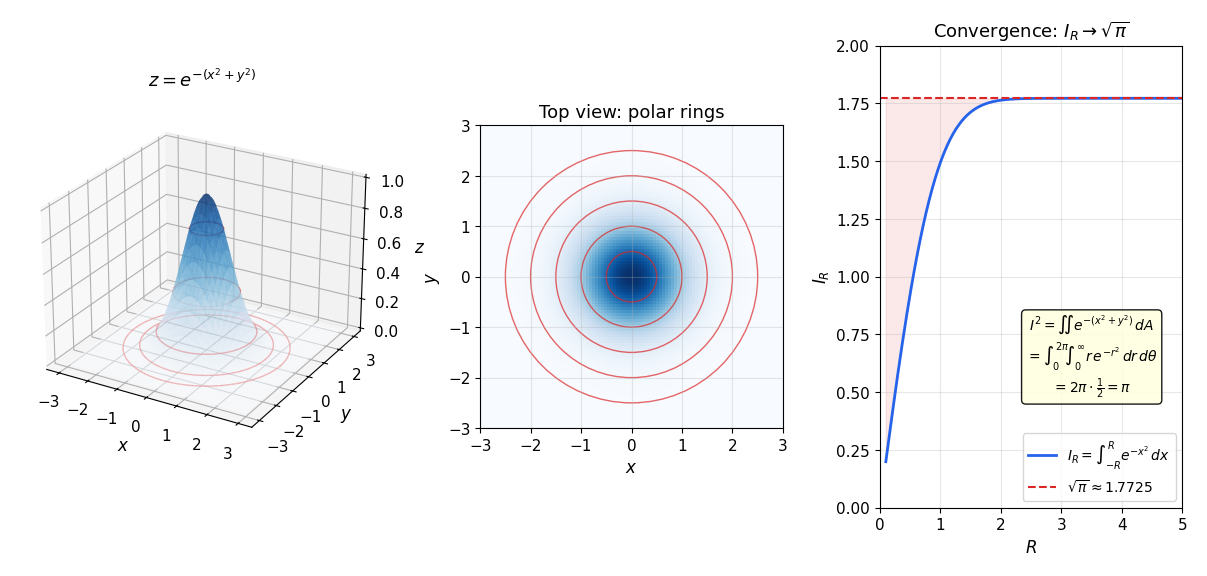

Figure 4 saved: gaussian-integral.png


In [5]:
fig = plt.figure(figsize=(15, 6))
gs = GridSpec(1, 3, width_ratios=[1.2, 1, 1], wspace=0.3)

# Left: 3D surface z = exp(-(x^2+y^2))
ax1 = fig.add_subplot(gs[0], projection='3d')
u = np.linspace(-3, 3, 100)
v = np.linspace(-3, 3, 100)
U, V = np.meshgrid(u, v)
Z = np.exp(-(U**2 + V**2))
ax1.plot_surface(U, V, Z, cmap='Blues', alpha=0.6, edgecolor='none')

# Add concentric polar rings
for r in [0.5, 1.0, 1.5, 2.0, 2.5]:
    theta_ring = np.linspace(0, 2*np.pi, 100)
    xr = r * np.cos(theta_ring)
    yr = r * np.sin(theta_ring)
    zr = np.exp(-r**2) * np.ones_like(theta_ring)
    ax1.plot(xr, yr, zr, color=RED, linewidth=1, alpha=0.7)

ax1.set_xlabel(r'$x$')
ax1.set_ylabel(r'$y$')
ax1.set_zlabel(r'$z$')
ax1.set_title(r'$z = e^{-(x^2 + y^2)}$', fontsize=13)
ax1.view_init(elev=25, azim=-60)

# Center: top-down heatmap
ax2 = fig.add_subplot(gs[1])
ax2.imshow(Z, extent=[-3, 3, -3, 3], origin='lower', cmap='Blues', aspect='equal')
for r in [0.5, 1.0, 1.5, 2.0, 2.5]:
    circle = plt.Circle((0, 0), r, fill=False, color=RED, linewidth=1, alpha=0.7)
    ax2.add_patch(circle)
ax2.set_xlabel(r'$x$')
ax2.set_ylabel(r'$y$')
ax2.set_title('Top view: polar rings', fontsize=13)

# Right: convergence of I_R to sqrt(pi)
ax3 = fig.add_subplot(gs[2])
R_vals = np.linspace(0.1, 5, 200)
I_R = np.array([integrate.quad(lambda x: np.exp(-x**2), -R, R)[0] for R in R_vals])
ax3.plot(R_vals, I_R, color=BLUE, linewidth=2, label=r'$I_R = \int_{-R}^{R} e^{-x^2}\,dx$')
ax3.axhline(y=np.sqrt(np.pi), color=RED, linestyle='--', linewidth=1.5, label=r'$\sqrt{\pi} \approx 1.7725$')
ax3.fill_between(R_vals, I_R, np.sqrt(np.pi), alpha=0.1, color=RED)
ax3.set_xlabel(r'$R$')
ax3.set_ylabel(r'$I_R$')
ax3.set_title(r'Convergence: $I_R \to \sqrt{\pi}$', fontsize=13)
ax3.legend(fontsize=10, loc='lower right')
ax3.set_xlim(0, 5)
ax3.set_ylim(0, 2)

ax3.annotate(
    r'$I^2 = \int\!\!\int e^{-(x^2+y^2)}\,dA$' + '\n'
    + r'$= \int_0^{2\pi}\!\int_0^\infty r\,e^{-r^2}\,dr\,d\theta$' + '\n'
    + r'$= 2\pi \cdot \frac{1}{2} = \pi$',
    xy=(3.5, 0.5), fontsize=10, ha='center',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.9))

plt.savefig('figures/gaussian-integral.png')
plt.show()
print('Figure 4 saved: gaussian-integral.png')

## 5. Cylindrical and Spherical Coordinates

The change of variables formula extends to 3D. **Cylindrical coordinates** $(r, \theta, z)$ with $dV = r\,dr\,d\theta\,dz$ are the natural choice for problems with cylindrical symmetry. **Spherical coordinates** $(\rho, \theta, \phi)$ with $dV = \rho^2\sin\phi\,d\rho\,d\theta\,d\phi$ handle spherical symmetry. We visualize both coordinate systems by drawing their coordinate surfaces.

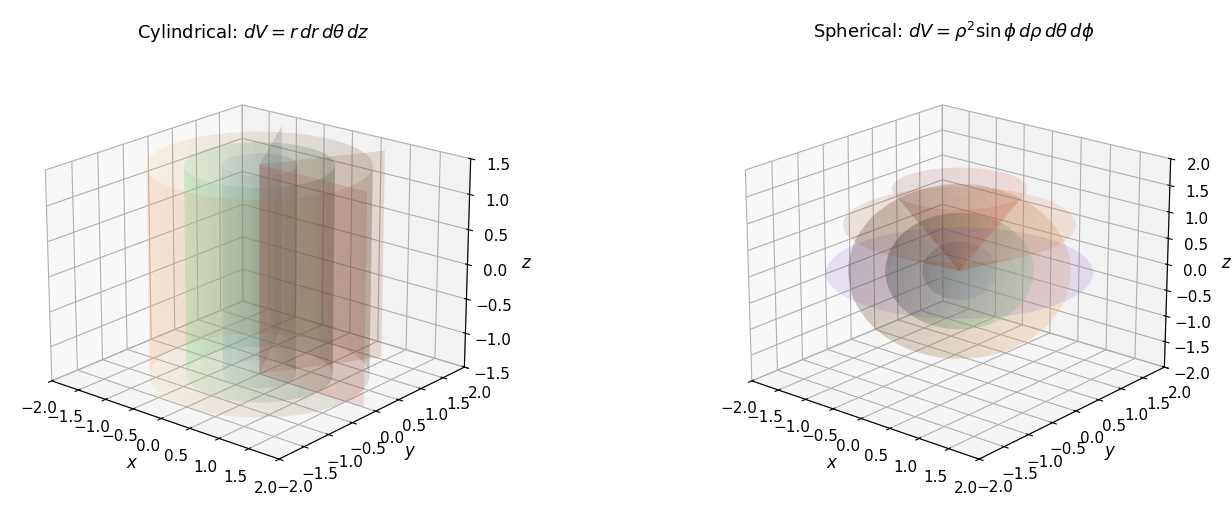

Figure 5 saved: coordinate-systems-3d.png


In [6]:
fig = plt.figure(figsize=(14, 6))

# Left: Cylindrical coordinate surfaces
ax1 = fig.add_subplot(121, projection='3d')
theta_cyl = np.linspace(0, 2*np.pi, 60)
z_cyl = np.linspace(-1.5, 1.5, 30)
Theta_c, Z_c = np.meshgrid(theta_cyl, z_cyl)

for r_val, al, col in [(0.5, 0.15, LIGHT_BLUE), (1.0, 0.2, LIGHT_GREEN), (1.5, 0.15, LIGHT_ORANGE)]:
    X_c = r_val * np.cos(Theta_c)
    Y_c = r_val * np.sin(Theta_c)
    ax1.plot_surface(X_c, Y_c, Z_c, alpha=al, color=col, edgecolor='none')

for t_val, col in [(0, RED), (np.pi/3, ORANGE), (2*np.pi/3, PURPLE)]:
    r_line = np.linspace(0, 1.8, 20)
    z_line = np.linspace(-1.5, 1.5, 20)
    R_p, Z_p = np.meshgrid(r_line, z_line)
    X_p = R_p * np.cos(t_val)
    Y_p = R_p * np.sin(t_val)
    ax1.plot_surface(X_p, Y_p, Z_p, alpha=0.15, color=col, edgecolor='none')

ax1.set_xlabel(r'$x$')
ax1.set_ylabel(r'$y$')
ax1.set_zlabel(r'$z$')
ax1.set_title(r'Cylindrical: $dV = r\,dr\,d\theta\,dz$', fontsize=13)
ax1.view_init(elev=20, azim=-50)
ax1.set_xlim(-2, 2); ax1.set_ylim(-2, 2); ax1.set_zlim(-1.5, 1.5)

# Right: Spherical coordinate surfaces
ax2 = fig.add_subplot(122, projection='3d')
theta_sph = np.linspace(0, 2*np.pi, 40)
phi_sph = np.linspace(0, np.pi, 30)
Theta_s, Phi_s = np.meshgrid(theta_sph, phi_sph)

for rho_val, al, col in [(0.5, 0.15, LIGHT_BLUE), (1.0, 0.2, LIGHT_GREEN), (1.5, 0.15, LIGHT_ORANGE)]:
    X_s = rho_val * np.sin(Phi_s) * np.cos(Theta_s)
    Y_s = rho_val * np.sin(Phi_s) * np.sin(Theta_s)
    Z_s = rho_val * np.cos(Phi_s)
    ax2.plot_surface(X_s, Y_s, Z_s, alpha=al, color=col, edgecolor='none')

for phi_val, col in [(np.pi/6, RED), (np.pi/3, ORANGE), (np.pi/2, PURPLE)]:
    r_cone = np.linspace(0, 1.8, 20)
    t_cone = np.linspace(0, 2*np.pi, 40)
    R_co, T_co = np.meshgrid(r_cone, t_cone)
    X_co = R_co * np.sin(phi_val) * np.cos(T_co)
    Y_co = R_co * np.sin(phi_val) * np.sin(T_co)
    Z_co = R_co * np.cos(phi_val)
    ax2.plot_surface(X_co, Y_co, Z_co, alpha=0.12, color=col, edgecolor='none')

ax2.set_xlabel(r'$x$')
ax2.set_ylabel(r'$y$')
ax2.set_zlabel(r'$z$')
ax2.set_title(r'Spherical: $dV = \rho^2\sin\phi\,d\rho\,d\theta\,d\phi$', fontsize=13)
ax2.view_init(elev=20, azim=-50)
ax2.set_xlim(-2, 2); ax2.set_ylim(-2, 2); ax2.set_zlim(-2, 2)

plt.subplots_adjust(left=0.05, right=0.95, wspace=0.25)
plt.savefig('figures/coordinate-systems-3d.png')
plt.show()
print('Figure 5 saved: coordinate-systems-3d.png')

## 6. Volume of the Unit Ball via Spherical Coordinates

We compute the volume of the unit ball $\{x^2 + y^2 + z^2 \le 1\}$ using spherical coordinates. The integral factors into three decoupled 1D integrals: $V = \int_0^{2\pi} d\theta \int_0^{\pi} \sin\phi\,d\phi \int_0^1 \rho^2\,d\rho = 2\pi \cdot 2 \cdot \frac{1}{3} = \frac{4\pi}{3}$. We also show the surprising behavior of $n$-ball volume as dimension increases.

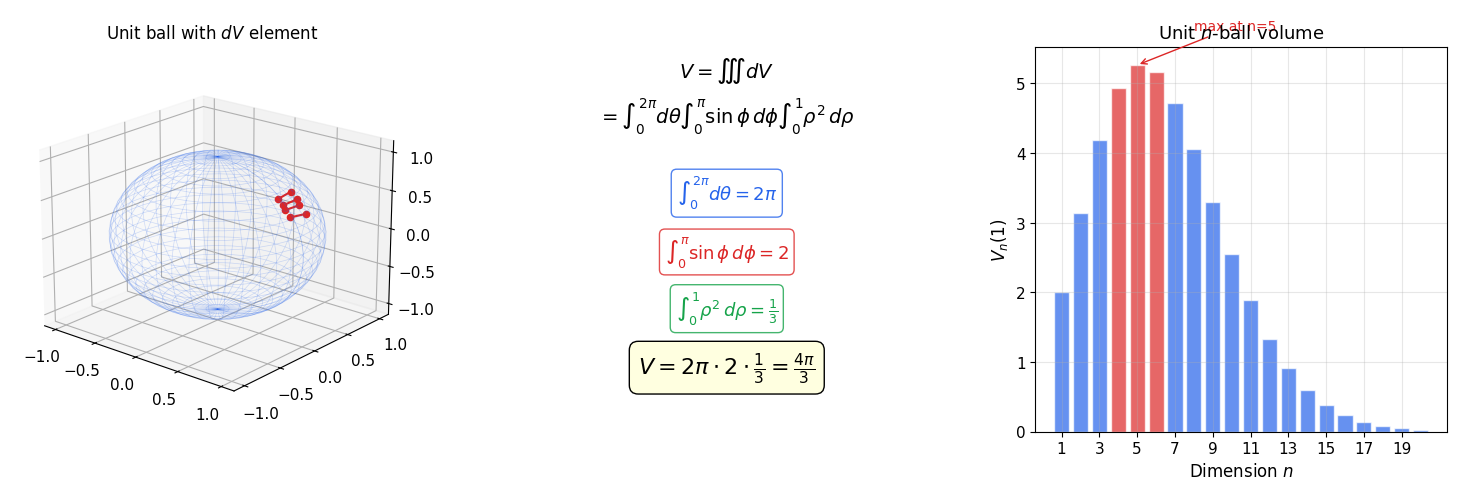

Figure 6 saved: spherical-volume.png


In [7]:
fig = plt.figure(figsize=(16, 5))

# Left: unit ball wireframe with volume element
ax1 = fig.add_subplot(131, projection='3d')
theta_ball = np.linspace(0, 2*np.pi, 40)
phi_ball = np.linspace(0, np.pi, 30)
T_b, P_b = np.meshgrid(theta_ball, phi_ball)
X_b = np.sin(P_b) * np.cos(T_b)
Y_b = np.sin(P_b) * np.sin(T_b)
Z_b = np.cos(P_b)
ax1.plot_wireframe(X_b, Y_b, Z_b, alpha=0.2, color=BLUE, linewidth=0.5)

# Highlight a volume element
rho0, theta0, phi0 = 0.7, np.pi/4, np.pi/3
drho, dtheta, dphi = 0.15, 0.3, 0.25
rho_e = np.array([rho0, rho0 + drho])
theta_e = np.array([theta0, theta0 + dtheta])
phi_e = np.array([phi0, phi0 + dphi])

for r in rho_e:
    for t in theta_e:
        for p in phi_e:
            ax1.scatter(r*np.sin(p)*np.cos(t), r*np.sin(p)*np.sin(t), r*np.cos(p),
                       color=RED, s=20, zorder=5)

for t in theta_e:
    for p in phi_e:
        r_line = np.linspace(rho_e[0], rho_e[1], 10)
        ax1.plot(r_line*np.sin(p)*np.cos(t), r_line*np.sin(p)*np.sin(t),
                r_line*np.cos(p), color=RED, linewidth=1.5)

ax1.set_title(r'Unit ball with $dV$ element', fontsize=12)
ax1.view_init(elev=20, azim=-50)

# Center: the three decoupled integrals
ax2 = fig.add_subplot(132)
ax2.axis('off')
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.text(5, 9.2, r'$V = \iiint dV$', fontsize=14, ha='center')
ax2.text(5, 8.0, r'$= \int_0^{2\pi} d\theta \int_0^{\pi} \sin\phi\,d\phi \int_0^1 \rho^2\,d\rho$',
         fontsize=14, ha='center')

for y_pos, integral, color in [
    (6.0, r'$\int_0^{2\pi} d\theta = 2\pi$', BLUE),
    (4.5, r'$\int_0^{\pi} \sin\phi\,d\phi = 2$', RED),
    (3.0, r'$\int_0^1 \rho^2\,d\rho = \frac{1}{3}$', GREEN),
]:
    ax2.text(5, y_pos, integral, fontsize=13, ha='center', color=color,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.8))

ax2.text(5, 1.5, r'$V = 2\pi \cdot 2 \cdot \frac{1}{3} = \frac{4\pi}{3}$',
         fontsize=16, ha='center', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='black'))

# Right: n-ball volume vs dimension
ax3 = fig.add_subplot(133)
from math import gamma as math_gamma
dims = np.arange(1, 21)
vols = [np.pi**(d/2) / math_gamma(d/2 + 1) for d in dims]
ax3.bar(dims, vols, color=[BLUE if v < max(vols)*0.9 else RED for v in vols],
        alpha=0.7, edgecolor='white')
ax3.set_xlabel('Dimension $n$')
ax3.set_ylabel(r'$V_n(1)$')
ax3.set_title(r'Unit $n$-ball volume', fontsize=13)
ax3.set_xticks(range(1, 21, 2))
max_idx = np.argmax(vols)
ax3.annotate(f'max at n={dims[max_idx]}',
             xy=(dims[max_idx], vols[max_idx]),
             xytext=(dims[max_idx]+3, vols[max_idx]+0.5),
             fontsize=10, arrowprops=dict(arrowstyle='->', color=RED), color=RED)

plt.subplots_adjust(left=0.05, right=0.95, wspace=0.25)
plt.savefig('figures/spherical-volume.png')
plt.show()
print('Figure 6 saved: spherical-volume.png')

## 7. General Diffeomorphisms — Grid Deformation Gallery

The change of variables formula works for any $C^1$ diffeomorphism, not just polar and spherical. We visualize how different transformations deform a uniform grid: shear, scaling, elliptical, and a nonlinear swirl. Each cell is colored by the local Jacobian determinant.

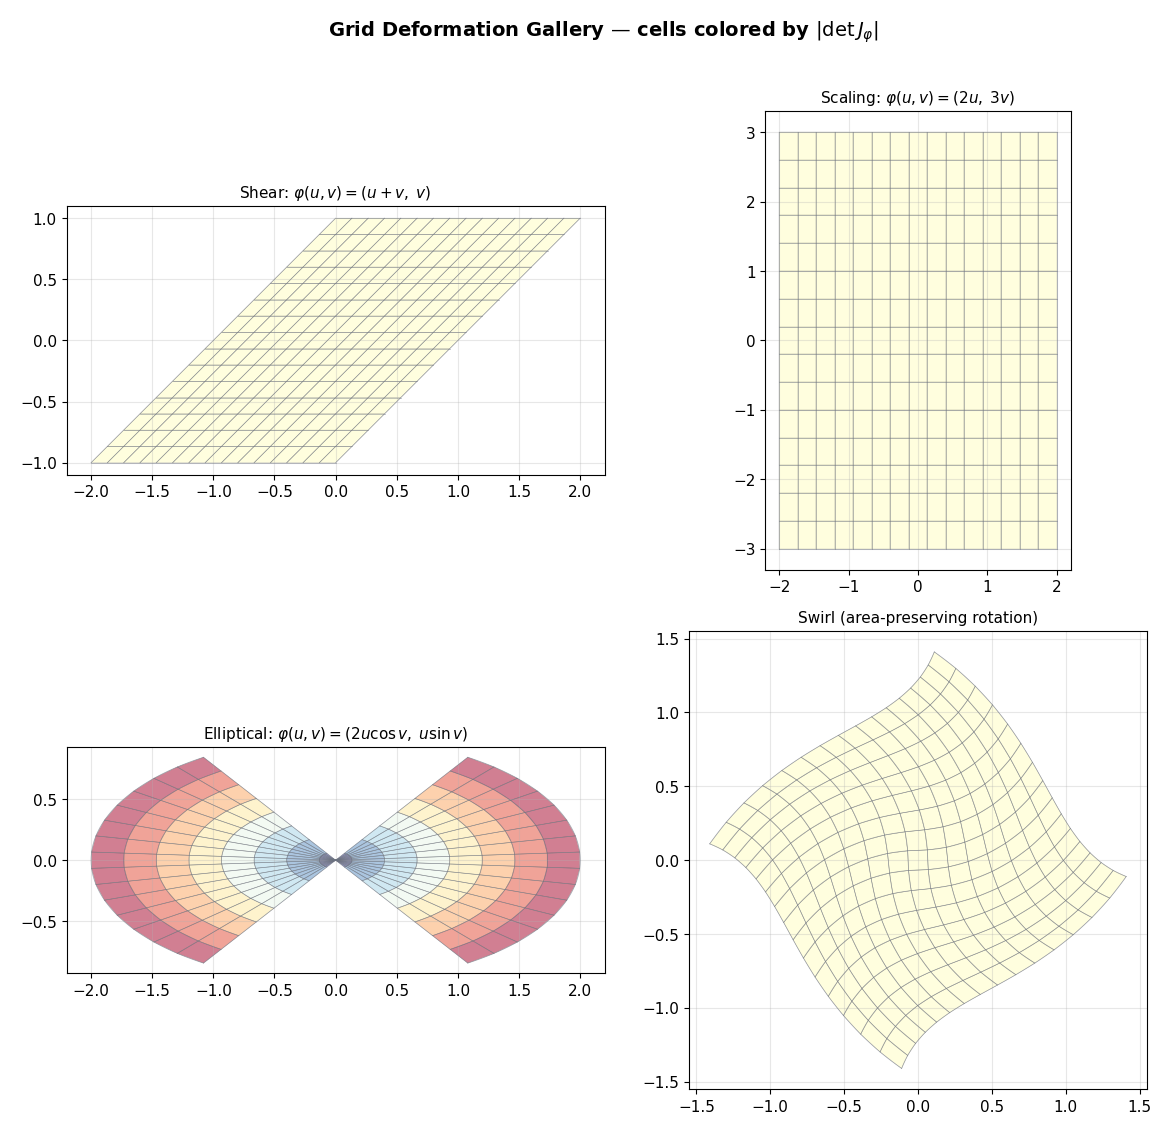

Figure 7 saved: transformation-gallery.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 11))

transforms = [
    {'name': r'Shear: $\varphi(u,v) = (u+v,\; v)$',
     'phi': lambda u, v: (u + v, v),
     'detJ': lambda u, v: np.ones_like(u)},
    {'name': r'Scaling: $\varphi(u,v) = (2u,\; 3v)$',
     'phi': lambda u, v: (2*u, 3*v),
     'detJ': lambda u, v: 6 * np.ones_like(u)},
    {'name': r'Elliptical: $\varphi(u,v) = (2u\cos v,\; u\sin v)$',
     'phi': lambda u, v: (2*u*np.cos(v), u*np.sin(v)),
     'detJ': lambda u, v: 2*np.abs(u)},
    {'name': 'Swirl (area-preserving rotation)',
     'phi': lambda u, v: (
         u * np.cos(np.sqrt(u**2 + v**2)/2) - v * np.sin(np.sqrt(u**2 + v**2)/2),
         u * np.sin(np.sqrt(u**2 + v**2)/2) + v * np.cos(np.sqrt(u**2 + v**2)/2)),
     'detJ': lambda u, v: np.ones_like(u)},
]

n_grid = 15
for ax, tr in zip(axes.flat, transforms):
    u_vals = np.linspace(-1, 1, n_grid + 1)
    v_vals = np.linspace(-1, 1, n_grid + 1)

    for i in range(n_grid + 1):
        v_line = np.linspace(-1, 1, 100)
        u_line = u_vals[i] * np.ones_like(v_line)
        x_line, y_line = tr['phi'](u_line, v_line)
        ax.plot(x_line, y_line, color=GRAY, linewidth=0.5, alpha=0.6)
        u_line2 = np.linspace(-1, 1, 100)
        v_line2 = v_vals[i] * np.ones_like(u_line2)
        x_line2, y_line2 = tr['phi'](u_line2, v_line2)
        ax.plot(x_line2, y_line2, color=GRAY, linewidth=0.5, alpha=0.6)

    polys = []
    det_vals = []
    for i in range(n_grid):
        for j in range(n_grid):
            corners_u = [u_vals[i], u_vals[i+1], u_vals[i+1], u_vals[i]]
            corners_v = [v_vals[j], v_vals[j], v_vals[j+1], v_vals[j+1]]
            corners_x, corners_y = tr['phi'](np.array(corners_u), np.array(corners_v))
            verts = list(zip(corners_x, corners_y))
            polys.append(verts)
            uc = (u_vals[i] + u_vals[i+1]) / 2
            vc = (v_vals[j] + v_vals[j+1]) / 2
            det_vals.append(float(np.abs(tr['detJ'](np.array([uc]), np.array([vc]))[0])))

    det_arr = np.array(det_vals)
    d_min, d_max = det_arr.min(), det_arr.max()
    if d_max - d_min < 0.01:
        d_min -= 0.5; d_max += 0.5
    norm = mcolors.Normalize(vmin=d_min, vmax=d_max)
    pc = PolyCollection(polys, cmap=plt.cm.RdYlBu_r, norm=norm, alpha=0.5,
                        edgecolors='gray', linewidths=0.3)
    pc.set_array(det_arr)
    ax.add_collection(pc)
    ax.set_title(tr['name'], fontsize=11)
    ax.set_aspect('equal')
    ax.autoscale_view()

plt.suptitle(r'Grid Deformation Gallery — cells colored by $|\det J_\varphi|$',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/transformation-gallery.png')
plt.show()
print('Figure 7 saved: transformation-gallery.png')

## 8. Density Transformation — From Calculus to Probability

The change of variables formula has a direct probabilistic interpretation: if $Z$ has density $p_Z(z)$ and $X = \varphi(Z)$, then $p_X(x) = p_Z(\varphi^{-1}(x)) \cdot |\det J_{\varphi^{-1}}(x)|$. We visualize this for the exponential map $X = e^Z$ producing the log-normal distribution.

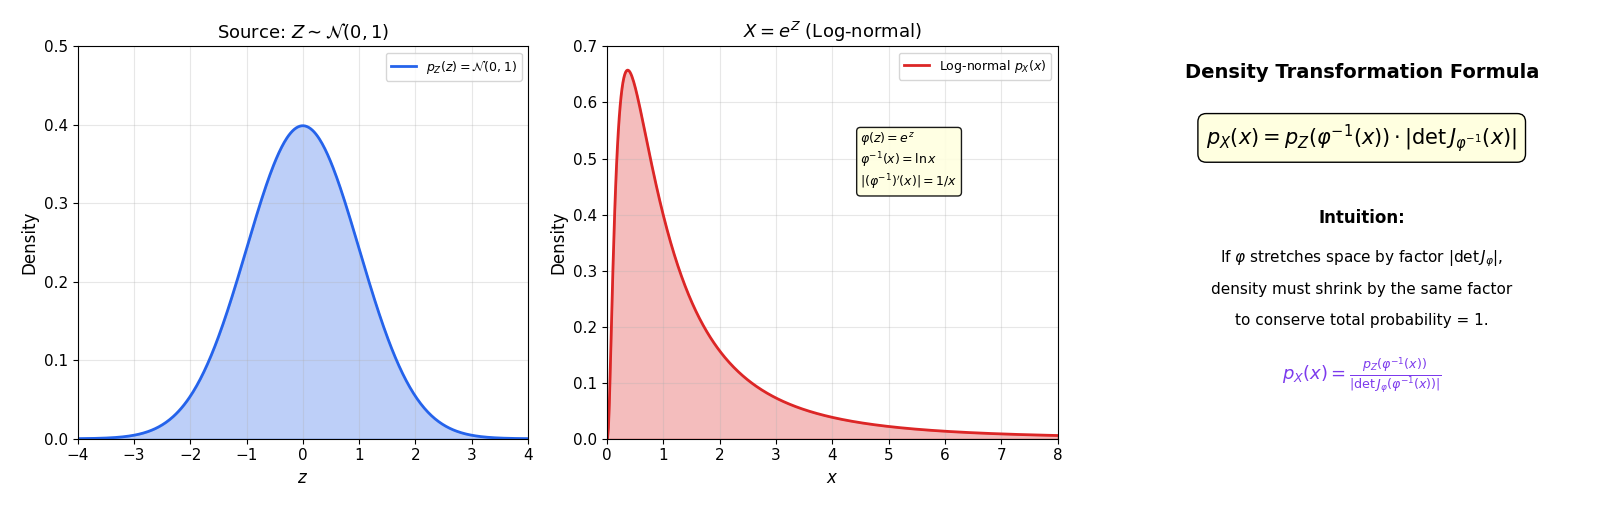

Figure 8 saved: density-transformation.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

z = np.linspace(-4, 4, 500)
pz = (1/np.sqrt(2*np.pi)) * np.exp(-z**2/2)

# Left: Standard normal
axes[0].fill_between(z, 0, pz, alpha=0.3, color=BLUE)
axes[0].plot(z, pz, color=BLUE, linewidth=2, label=r'$p_Z(z) = \mathcal{N}(0,1)$')
axes[0].set_xlabel(r'$z$')
axes[0].set_ylabel('Density')
axes[0].set_title(r'Source: $Z \sim \mathcal{N}(0,1)$', fontsize=13)
axes[0].legend(fontsize=9)
axes[0].set_xlim(-4, 4)
axes[0].set_ylim(0, 0.5)

# Center: Log-normal via X = exp(Z)
x_ln = np.linspace(0.01, 8, 500)
px_ln = (1/(x_ln * np.sqrt(2*np.pi))) * np.exp(-np.log(x_ln)**2 / 2)
axes[1].fill_between(x_ln, 0, px_ln, alpha=0.3, color=RED)
axes[1].plot(x_ln, px_ln, color=RED, linewidth=2, label=r'Log-normal $p_X(x)$')
axes[1].set_xlabel(r'$x$')
axes[1].set_ylabel('Density')
axes[1].set_title(r'$X = e^Z$ (Log-normal)', fontsize=13)
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 8)
axes[1].set_ylim(0, 0.7)
axes[1].annotate(
    r'$\varphi(z) = e^z$' + '\n'
    + r'$\varphi^{-1}(x) = \ln x$' + '\n'
    + r"$|(\varphi^{-1})'(x)| = 1/x$",
    xy=(4.5, 0.45), fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.9))

# Right: formula summary
axes[2].axis('off')
axes[2].set_xlim(0, 10)
axes[2].set_ylim(0, 10)
axes[2].text(5, 9.2, 'Density Transformation Formula', fontsize=14, ha='center', fontweight='bold')
axes[2].text(5, 7.5, r'$p_X(x) = p_Z(\varphi^{-1}(x)) \cdot |\det J_{\varphi^{-1}}(x)|$',
             fontsize=15, ha='center',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='black'))
axes[2].text(5, 5.5, 'Intuition:', fontsize=12, ha='center', fontweight='bold')
axes[2].text(5, 4.5, r'If $\varphi$ stretches space by factor $|\det J_\varphi|$,',
             fontsize=11, ha='center')
axes[2].text(5, 3.7, 'density must shrink by the same factor', fontsize=11, ha='center')
axes[2].text(5, 2.9, 'to conserve total probability = 1.', fontsize=11, ha='center')
axes[2].text(5, 1.5, r'$p_X(x) = \frac{p_Z(\varphi^{-1}(x))}{|\det J_\varphi(\varphi^{-1}(x))|}$',
             fontsize=13, ha='center', color=PURPLE)

plt.tight_layout()
plt.savefig('figures/density-transformation.png')
plt.show()
print('Figure 8 saved: density-transformation.png')

## 9. ML Connections: Normalizing Flows and the Reparameterization Trick

In machine learning, the change of variables formula is the mathematical engine of **normalizing flows**. A normalizing flow is a composition of diffeomorphisms $x = f_K \circ f_{K-1} \circ \cdots \circ f_1(z)$ that transforms a simple distribution into a complex one. The density of $x$ is:

$$\log p_X(x) = \log p_Z(z) - \sum_{k=1}^K \log |\det J_{f_k}(z_{k-1})|$$

The **reparameterization trick** in VAEs is the same idea: write $z = \mu + \sigma\epsilon$ with $\epsilon \sim \mathcal{N}(0,1)$ to move parameters outside the expectation.

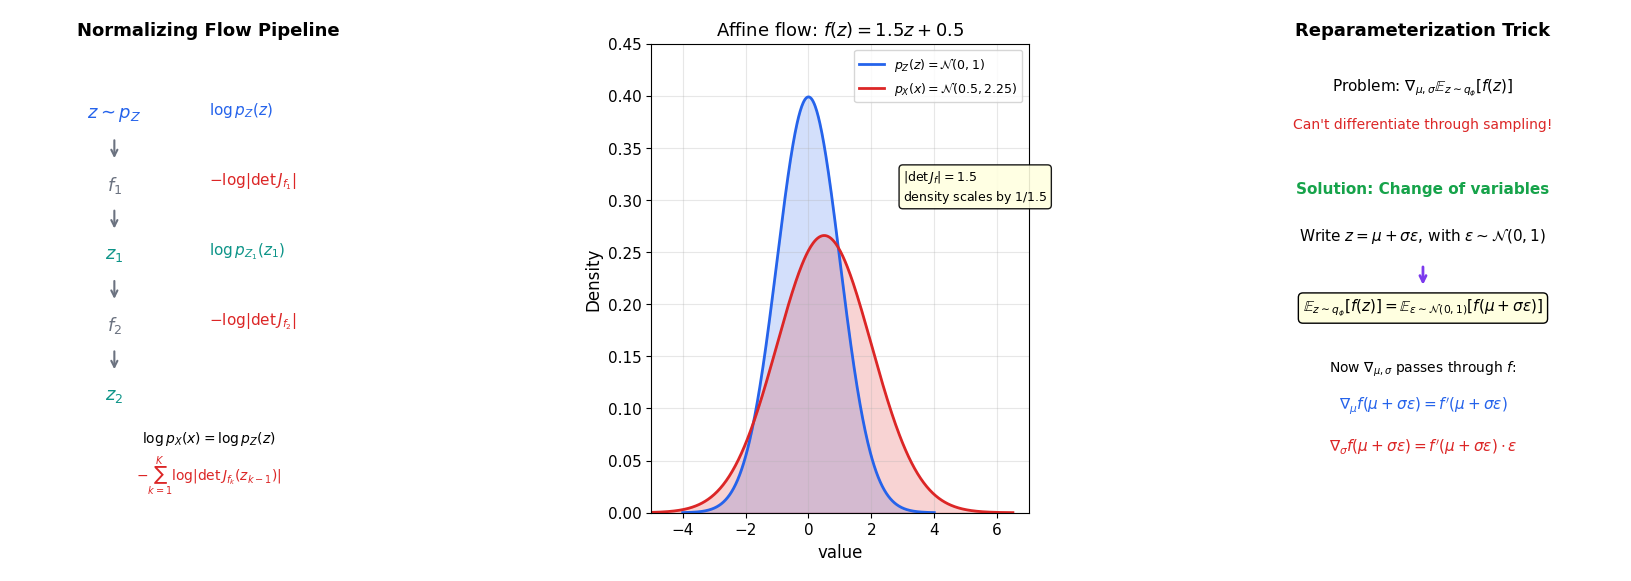

Figure 9 saved: ml-normalizing-flows.png


In [10]:
fig = plt.figure(figsize=(16, 5.5), layout="constrained")
gs = GridSpec(1, 3, wspace=0.35, figure=fig)

# Panel 1: Normalizing flow pipeline
ax1 = fig.add_subplot(gs[0])
ax1.axis('off')
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.set_title('Normalizing Flow Pipeline', fontsize=13, fontweight='bold')

stages = [
    (1, 8.5, r'$z \sim p_Z$', BLUE),
    (1, 7.0, r'$f_1$', GRAY),
    (1, 5.5, r'$z_1$', TEAL),
    (1, 4.0, r'$f_2$', GRAY),
    (1, 2.5, r'$z_2$', TEAL),
]
for x_pos, y_pos, label, color in stages:
    ax1.text(x_pos + 1.5, y_pos, label, fontsize=13, ha='center', va='center',
             color=color, fontweight='bold')

ax1.text(5, 8.5, r'$\log p_Z(z)$', fontsize=11, ha='left', color=BLUE)
ax1.text(5, 7.0, r'$-\log|\det J_{f_1}|$', fontsize=11, ha='left', color=RED)
ax1.text(5, 5.5, r'$\log p_{Z_1}(z_1)$', fontsize=11, ha='left', color=TEAL)
ax1.text(5, 4.0, r'$-\log|\det J_{f_2}|$', fontsize=11, ha='left', color=RED)

ax1.text(5, 1.5, r'$\log p_X(x) = \log p_Z(z)$', fontsize=10, ha='center')
ax1.text(5, 0.7, r'$- \sum_{k=1}^K \log|\det J_{f_k}(z_{k-1})|$', fontsize=10, ha='center', color=RED)

for y_s, y_e in [(8.0, 7.5), (6.5, 6.0), (5.0, 4.5), (3.5, 3.0)]:
    ax1.annotate('', xy=(2.5, y_e), xytext=(2.5, y_s),
                arrowprops=dict(arrowstyle='->', color=GRAY, lw=1.5))

# Panel 2: 1D flow example
ax2 = fig.add_subplot(gs[1])
z_vals = np.linspace(-4, 4, 500)
pz_vals = (1/np.sqrt(2*np.pi)) * np.exp(-z_vals**2/2)
mu_shift, sigma_scale = 0.5, 1.5
x_vals = sigma_scale * z_vals + mu_shift
px_vals = pz_vals / sigma_scale

ax2.fill_between(z_vals, 0, pz_vals, alpha=0.2, color=BLUE)
ax2.plot(z_vals, pz_vals, color=BLUE, linewidth=2, label=r'$p_Z(z) = \mathcal{N}(0,1)$')
ax2.fill_between(x_vals, 0, px_vals, alpha=0.2, color=RED)
ax2.plot(x_vals, px_vals, color=RED, linewidth=2, label=r'$p_X(x) = \mathcal{N}(0.5, 2.25)$')
ax2.set_xlabel('value')
ax2.set_ylabel('Density')
ax2.set_title(r'Affine flow: $f(z) = 1.5z + 0.5$', fontsize=13)
ax2.legend(fontsize=9)
ax2.set_xlim(-5, 7)
ax2.set_ylim(0, 0.45)
ax2.annotate(r'$|\det J_f| = 1.5$' + '\n' + r'density scales by $1/1.5$',
             xy=(3, 0.3), fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.9))

# Panel 3: Reparameterization trick
ax3 = fig.add_subplot(gs[2])
ax3.axis('off')
ax3.set_xlim(0, 10)
ax3.set_ylim(0, 10)
ax3.set_title('Reparameterization Trick', fontsize=13, fontweight='bold')
ax3.text(5, 9.0, r'Problem: $\nabla_{\mu,\sigma} \mathbb{E}_{z \sim q_\phi}[f(z)]$', fontsize=11, ha='center')
ax3.text(5, 8.2, "Can't differentiate through sampling!", fontsize=10, ha='center', color=RED)
ax3.text(5, 6.8, 'Solution: Change of variables', fontsize=11, ha='center', fontweight='bold', color=GREEN)
ax3.text(5, 5.8, r'Write $z = \mu + \sigma\epsilon$, with $\epsilon \sim \mathcal{N}(0,1)$',
         fontsize=11, ha='center')
ax3.annotate('', xy=(5, 4.8), xytext=(5, 5.3),
            arrowprops=dict(arrowstyle='->', color=PURPLE, lw=2))
ax3.text(5, 4.3, r'$\mathbb{E}_{z \sim q_\phi}[f(z)] = \mathbb{E}_{\epsilon \sim \mathcal{N}(0,1)}[f(\mu + \sigma\epsilon)]$',
         fontsize=11, ha='center',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='black'))
ax3.text(5, 3.0, r'Now $\nabla_{\mu,\sigma}$ passes through $f$:', fontsize=10, ha='center')
ax3.text(5, 2.2, r"$\nabla_\mu f(\mu + \sigma\epsilon) = f'(\mu + \sigma\epsilon)$", fontsize=11, ha='center', color=BLUE)
ax3.text(5, 1.3, r"$\nabla_\sigma f(\mu + \sigma\epsilon) = f'(\mu + \sigma\epsilon) \cdot \epsilon$", fontsize=11, ha='center', color=RED)

plt.savefig('figures/ml-normalizing-flows.png')
plt.show()
print('Figure 9 saved: ml-normalizing-flows.png')

## Summary of Figures

| # | Filename | Description |
|---|----------|-------------|
| 1 | `1d-substitution.png` | 1D substitution: original vs. transformed integral with $x = \sin\theta$ |
| 2 | `change-of-variables-2d.png` | Polar grid deformation: uniform $(r,\theta)$ grid mapped to $(x,y)$, cells colored by $|\det J| = r$ |
| 3 | `polar-coordinates.png` | Cartesian vs. polar computation of unit disk area |
| 4 | `gaussian-integral.png` | 3D Gaussian surface $e^{-(x^2+y^2)}$ with polar rings, convergence $I_R \to \sqrt{\pi}$ |
| 5 | `coordinate-systems-3d.png` | Cylindrical and spherical coordinate surfaces side-by-side |
| 6 | `spherical-volume.png` | Unit ball volume via spherical coords, $n$-ball volume vs. dimension |
| 7 | `transformation-gallery.png` | Four-panel grid deformation gallery: shear, scaling, elliptical, swirl |
| 8 | `density-transformation.png` | Density transformation: $\mathcal{N}(0,1)$ to log-normal via $X = e^Z$ |
| 9 | `ml-normalizing-flows.png` | Normalizing flow pipeline, affine flow density, reparameterization trick |

All figures use the formalCalculus color palette and are saved at 200 DPI for web publication.